<a href="https://colab.research.google.com/github/vennelaR123/vennelaa/blob/main/skin_cancer_model_building_codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import shutil
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

In [ ]:
import os
import numpy as np
import shutil
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

# Paths for dataset folders
input_dataset = "/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train"
output_dataset = "/kaggle/working/dataset2"

# Ensure the output dataset directory exists
if os.path.exists(output_dataset):
    shutil.rmtree(output_dataset)  # Remove old dataset if it exists
os.makedirs(output_dataset)

# Define basic augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# Required class names
required_classes =[
    "actinic keratosis",
    "basal cell carcinoma",
    "dermatofibroma",
    "melanoma",
    "nevus",
    "pigmented benign keratosis",
    "seborrheic keratosis",
    "squamous cell carcinoma",
    "vascular lesion"
]

# Process each class folder
for class_name in tqdm(required_classes, desc="Processing Classes"):
    class_path = os.path.join(input_dataset, class_name)

    if not os.path.exists(class_path):
        print(f"❌ Skipping {class_name}, folder not found.")
        continue

    # Create the new output class folder
    output_class_path = os.path.join(output_dataset, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    # Load all images from the class folder
    images = [os.path.join(class_path, img) for img in os.listdir(class_path) if img.endswith(('png', 'jpg', 'jpeg'))]

    # Generate exactly 1000 augmented images
    num_images_generated = 0
    image_index = 0

    with tqdm(total=1000, desc=f"Augmenting {class_name}", leave=False) as pbar:
        while num_images_generated < 1000:
            img_path = images[image_index % len(images)]  # Loop through existing images
            img = load_img(img_path)  # Load image
            img = img.resize((100, 100))  # Resize to 100x100
            img_array = img_to_array(img)  # Convert to array
            img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions

            # Generate augmented images
            aug_iter = datagen.flow(img_array, batch_size=1)
            for _ in range(min(1000 - num_images_generated, 5)):  # Generate up to 5 images per iteration
                augmented_img = array_to_img(next(aug_iter)[0])  # Convert back to image
                augmented_img = augmented_img.resize((100, 100))  # Resize again to ensure size
                save_path = os.path.join(output_class_path, f"aug_{num_images_generated}.png")
                augmented_img.save(save_path)  # Save image
                num_images_generated += 1
                pbar.update(1)  # Update progress bar

            image_index += 1  # Move to the next image

print("✅ Data augmentation complete. Augmented dataset saved in 'dataset7'.")

Augmenting pigmented benign keratosis:  49%|████▉     | 492/1000 [00:04<00:04, 113.63it/s]

In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm

def preprocess_and_save_with_subclasses2(input_dir, output_dir, target_size=(100,100)):
    """
    Preprocess images from input directory (with subclasses) and save to output directory.
    - Maintains the original folder structure (subclasses).
    - Applies image preprocessing: grayscale, CLAHE, Gaussian blur, Canny edge detection, and overlays edges in red.
    """
    # Initialize CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    list1=os.listdir(input_dir)

    for subclass in list1:
        subclass_path = os.path.join(input_dir, subclass)
        if not os.path.isdir(subclass_path):
            continue  # Skip files, only process folders

        # Create corresponding subclass folder in the output directory
        output_subclass_path = os.path.join(output_dir, subclass)
        if not os.path.exists(output_subclass_path):
            os.makedirs(output_subclass_path)

        # Process each image in the subclass folder
        for image_name in tqdm(os.listdir(subclass_path), desc=f"Processing {subclass}"):
            image_path = os.path.join(subclass_path, image_name)
            image = cv2.imread(image_path)

            if image is None:
                continue  # Skip invalid files

            # Resize image
            image = cv2.resize(image, target_size)

            # Convert to grayscale
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            # Apply CLAHE for contrast enhancement
            clahe_enhanced = clahe.apply(gray)

            # Apply Gaussian blur to reduce noise
            blurred = cv2.GaussianBlur(clahe_enhanced, (5, 5), 0)

            # Apply Canny edge detection
            edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

            # Create an RGB edge map (edges in red)
            edges_colored = np.zeros_like(image)  # Create a black RGB image
            edges_colored[:, :, 2] = edges  # Set red channel to edges

            # Overlay the edges onto the original image
            combined = cv2.addWeighted(image, 0.8, edges_colored, 0.5, 0)

            # Save the processed image to the corresponding output folder
            output_path = os.path.join(output_subclass_path, image_name)
            cv2.imwrite(output_path, combined)

In [ ]:
# Define input and output directories
input_directory = '/kaggle/working/dataset2'  # Contains subclass folders
output_directory = '/kaggle/working/dataset6'  # Preprocessed images will be saved here

# Run preprocessing
preprocess_and_save_with_subclasses2(input_directory, output_directory)


Processing pigmented benign keratosis: 100%|██████████| 1000/1000 [00:02<00:00, 472.12it/s]


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
import cv2
import os
import random

In [ ]:
import os
import cv2
import numpy as np

def load_dataset(path_dataset, target_size=(100,100)):
    dataset = []
    labels = []

    # Iterate over all folders in dataset_path
    for label in os.listdir(path_dataset):
        class_path = os.path.join(path_dataset, label)

        # check if the directory exists
        if os.path.isdir(class_path):
            # Initialize a counter for images in each class
            images_counter = 0

            # Iterate over all images in folder/class
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)

                # Load image with OpenCV
                image = cv2.imread(image_path)

                # Check if the image was loaded successfully
                if image is not None:
                    # Resize the image
                    image = cv2.resize(image, target_size)
                    # Get image dimensions
                    (h, w) = image.shape[:2]

                    # Step 1: Apply random rotation between 0 to 5 degrees
                    angle = random.uniform(0, 5)  # Random angle between 0 and 5 degrees
                    center = (w // 2, h // 2)  # Center of the image
                    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)  # Rotation matrix
                    rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h))

                    # Step 2: Apply right-to-left flip
                    image = cv2.flip(rotated_image, 1)  # Flip horizontally
                    # Add image and label to dataset
                    dataset.append(image)
                    labels.append(label)


                else:
                    print(f"Error loading image: {image_path}")

    return np.array(dataset), np.array(labels)

dataset_path = "/kaggle/working/dataset6"
dataset, labels = load_dataset(dataset_path)

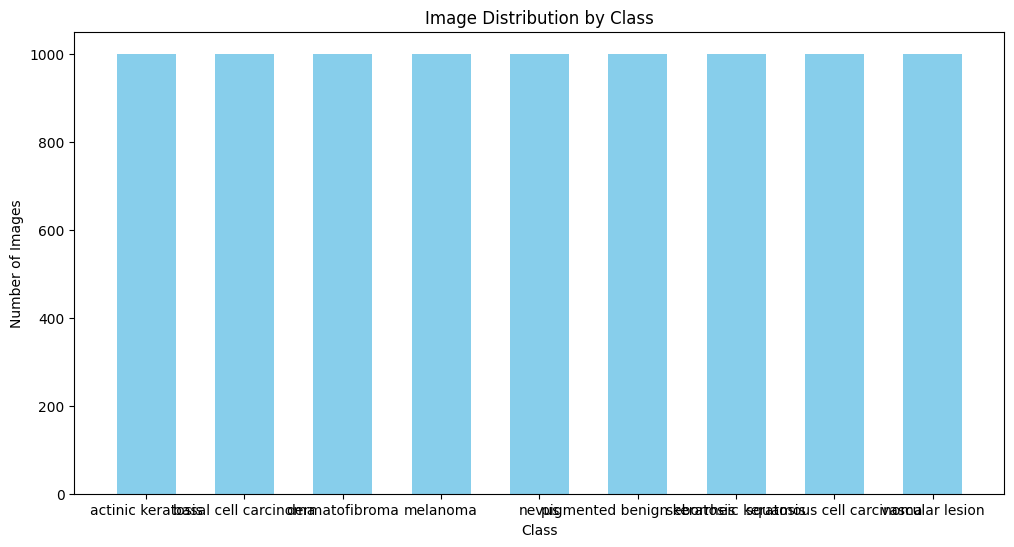

In [ ]:
unique_labels, counts = np.unique(labels, return_counts=True)
class_counts = dict(zip(unique_labels, counts))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(class_counts.keys(), class_counts.values(), color='skyblue', width=0.6)

ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_title('Image Distribution by Class')

plt.show()

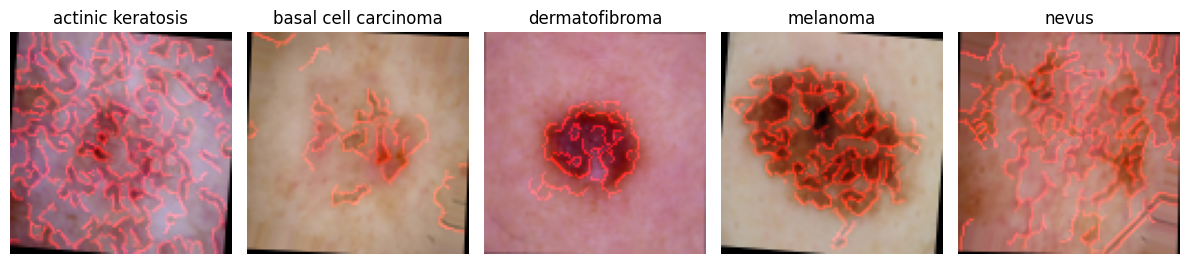

In [ ]:
import random
import matplotlib.pyplot as plt

def show_samples(dataset, labels, classes, num_samples):
    plt.figure(figsize=(12, 6))

    for i, class_name in enumerate(classes[:num_samples]):  # Show only the first num_samples classes
        indices_class = np.where(labels == class_name)[0]
        sample_index = random.choice(indices_class)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(cv2.cvtColor(dataset[sample_index], cv2.COLOR_BGR2RGB))
        plt.title(f'{class_name}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


unique_classes = np.unique(labels)
show_samples(dataset, labels, unique_classes, num_samples=5)by

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels into numbers
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)



X_train, X_temp, y_train, y_temp = train_test_split(dataset, encoded_labels, test_size=0.2, random_state=42)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


def preprocess_image(image):
    resized_image = cv2.resize(image, (100,100))

    normalized_image = resized_image / 255.0
    return normalized_image


X_train = np.array([preprocess_image(image) for image in X_train])
X_test = np.array([preprocess_image(image) for image in X_test])
X_val = np.array([preprocess_image(image) for image in X_val])


print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (7200, 100, 100, 3)
Shape of X_val: (900, 100, 100, 3)
Shape of X_test: (900, 100, 100, 3)
Shape of y_train: (7200,)
Shape of y_val: (900,)
Shape of y_test: (900,)


In [ ]:
!pip install efficientnet

  Obtaining dependency information for efficientnet from https://files.pythonhosted.org/packages/53/97/84f88e581d6ac86dcf1ab347c497c4c568c38784e3a2bd659b96912ab793/efficientnet-1.1.1-py3-none-any.whl.metadata
  Obtaining dependency information for keras-applications<=1.0.8,>=1.0.7 from https://files.pythonhosted.org/packages/71/e3/19762fdfc62877ae9102edf6342d71b28fbfd9dea3d2f96a882ce099b03f/Keras_Applications-1.0.8-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.6 MB/s eta 0:00:00


In [ ]:
from efficientnet.tfkeras import EfficientNetB0
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1
from tensorflow.keras.optimizers import RMSprop
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np


num_classes = len(np.unique(labels))

model = models.Sequential()

efficientnet_model = EfficientNetB0(input_shape=(100,100, 3), include_top=False, weights='imagenet', pooling='max')

model.add(efficientnet_model)

model.add(Dense(128, kernel_regularizer=l1(0.0001),activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(64, kernel_regularizer=l1(0.0001),activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(32, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(units=num_classes, activation='softmax'))

early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

custom_optimizer = RMSprop(learning_rate=0.0001)
model.compile(optimizer=custom_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))

16804768/16804768 [==============================] - 0s 0us/step
Epoch 1/30


2025-02-14 06:40:02.524885: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnet-b0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


225/225 [==============================] - 45s 65ms/step - loss: 3.2029 - accuracy: 0.1946 - val_loss: 2.9567 - val_accuracy: 0.1522
Epoch 2/30
225/225 [==============================] - 12s 54ms/step - loss: 2.6714 - accuracy: 0.3001 - val_loss: 2.2813 - val_accuracy: 0.4189
Epoch 3/30
225/225 [==============================] - 12s 54ms/step - loss: 2.3936 - accuracy: 0.3819 - val_loss: 2.0492 - val_accuracy: 0.5022
Epoch 4/30
225/225 [==============================] - 12s 53ms/step - loss: 2.1294 - accuracy: 0.4744 - val_loss: 1.8207 - val_accuracy: 0.6000
Epoch 5/30
225/225 [==============================] - 12s 54ms/step - loss: 1.9374 - accuracy: 0.5411 - val_loss: 1.6487 - val_accuracy: 0.6544
Epoch 6/30
225/225 [==============================] - 12s 54ms/step - loss: 1.7444 - accuracy: 0.6115 - val_loss: 1.4872 - val_accuracy: 0.7111
Epoch 7/30
225/225 [==============================] - 12s 54ms/step - loss: 1.5864 - accuracy: 0.6675 - val_loss: 1.3531 - val_accuracy: 0.7500
Epo

In [ ]:
# Save the weights of the model to a file
model.save_weights('efficientnet_skin_cancer.h5')

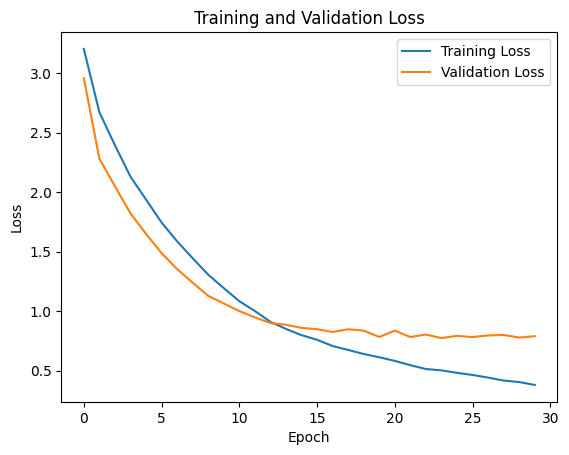

In [ ]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

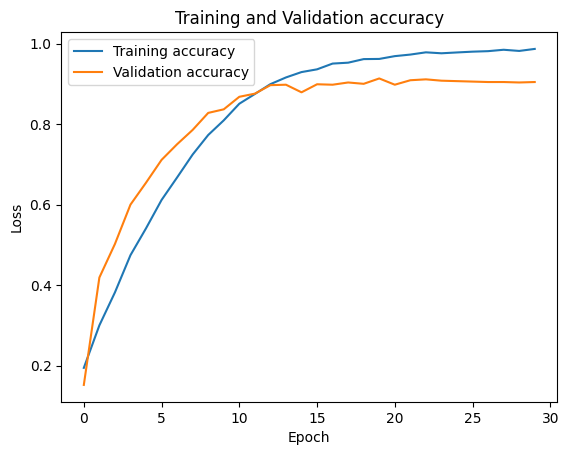

In [ ]:
# Plot training and validation loss
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

29/29 [==============================] - 2s 13ms/step
Test Accuracy: 0.9089


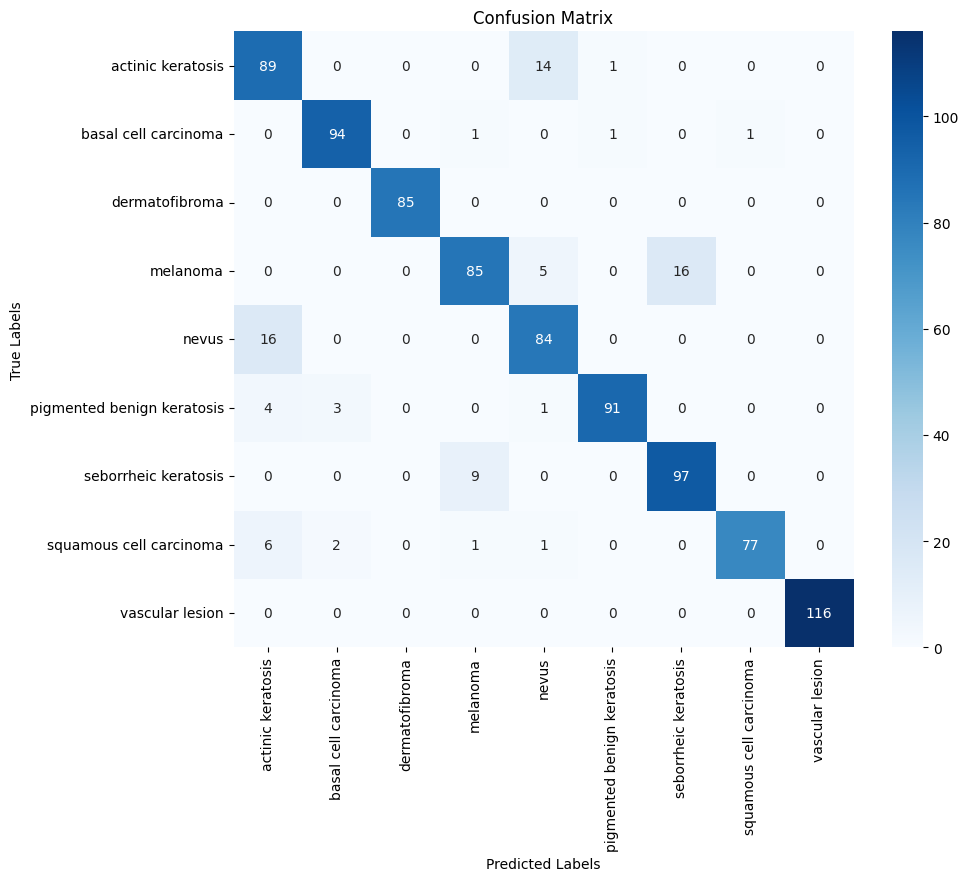

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis     0.7739    0.8558    0.8128       104
      basal cell carcinoma     0.9495    0.9691    0.9592        97
            dermatofibroma     1.0000    1.0000    1.0000        85
                  melanoma     0.8854    0.8019    0.8416       106
                     nevus     0.8000    0.8400    0.8195       100
pigmented benign keratosis     0.9785    0.9192    0.9479        99
      seborrheic keratosis     0.8584    0.9151    0.8858       106
   squamous cell carcinoma     0.9872    0.8851    0.9333        87
           vascular lesion     1.0000    1.0000    1.0000       116

                  accuracy                         0.9089       900
                 macro avg     0.9148    0.9096    0.9111       900
              weighted avg     0.9124    0.9089    0.9096       900



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and predicted classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test

# Calculate test accuracy
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_, digits=4))


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1
from tensorflow.keras.optimizers import RMSprop
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

num_classes = len(np.unique(labels))

model = models.Sequential()

resnet_model = ResNet50(input_shape=(100, 100, 3), include_top=False, weights='imagenet', pooling='max')

model.add(resnet_model)

model.add(Dense(128, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(64, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(32, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(units=num_classes, activation='softmax'))

early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

custom_optimizer = RMSprop(learning_rate=0.0001)
model.compile(optimizer=custom_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))


94765736/94765736 [==============================] - 3s 0us/step
Epoch 1/30
225/225 [==============================] - 42s 70ms/step - loss: 3.0017 - accuracy: 0.2907 - val_loss: 6.9846 - val_accuracy: 0.1144
Epoch 2/30
225/225 [==============================] - 14s 63ms/step - loss: 2.2282 - accuracy: 0.4921 - val_loss: 17.4665 - val_accuracy: 0.1011
Epoch 3/30
225/225 [==============================] - 14s 63ms/step - loss: 1.8867 - accuracy: 0.6256 - val_loss: 17.5099 - val_accuracy: 0.0711
Epoch 4/30
225/225 [==============================] - 14s 63ms/step - loss: 1.5790 - accuracy: 0.7390 - val_loss: 2.9356 - val_accuracy: 0.3256
Epoch 5/30
225/225 [==============================] - 14s 63ms/step - loss: 1.3197 - accuracy: 0.8236 - val_loss: 1.7604 - val_accuracy: 0.6389
Epoch 6/30
225/225 [==============================] - 14s 62ms/step - loss: 1.1478 - accuracy: 0.8675 - val_loss: 1.2328 - val_accuracy: 0.8167
Epoch 7/30
225/225 [==============================] - 14s 62ms/step -

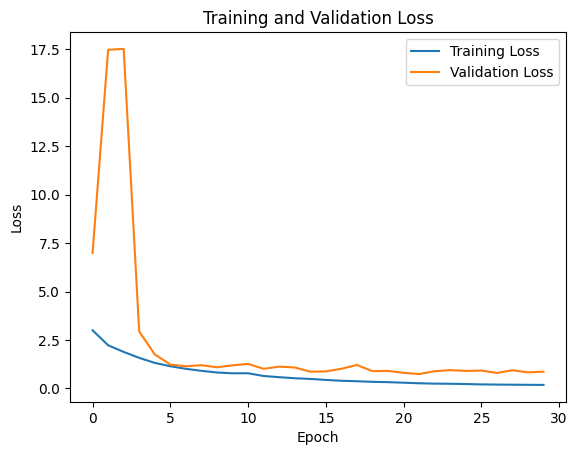

In [ ]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

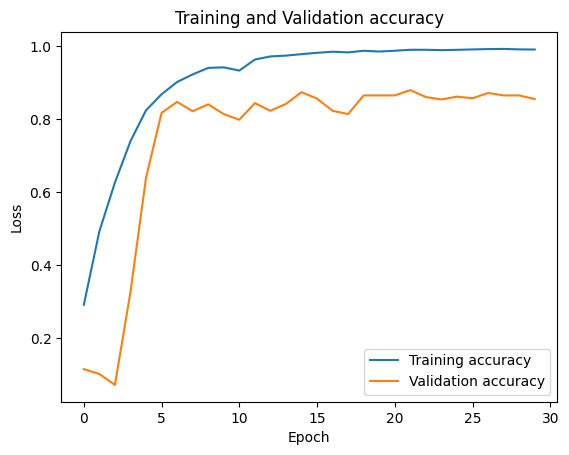

In [ ]:
# Plot training and validation loss
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

29/29 [==============================] - 1s 18ms/step
Test Accuracy: 0.8833


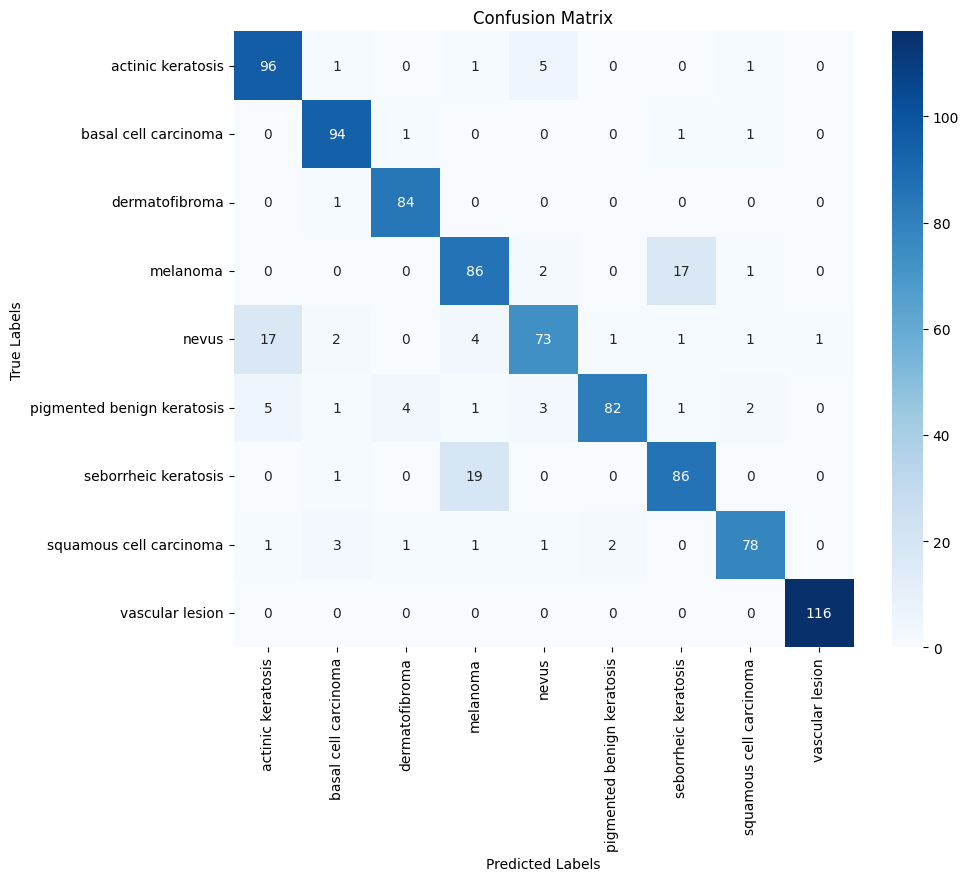

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis     0.8067    0.9231    0.8610       104
      basal cell carcinoma     0.9126    0.9691    0.9400        97
            dermatofibroma     0.9333    0.9882    0.9600        85
                  melanoma     0.7679    0.8113    0.7890       106
                     nevus     0.8690    0.7300    0.7935       100
pigmented benign keratosis     0.9647    0.8283    0.8913        99
      seborrheic keratosis     0.8113    0.8113    0.8113       106
   squamous cell carcinoma     0.9286    0.8966    0.9123        87
           vascular lesion     0.9915    1.0000    0.9957       116

                  accuracy                         0.8833       900
                 macro avg     0.8873    0.8842    0.8838       900
              weighted avg     0.8859    0.8833    0.8827       900



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and predicted classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test

# Calculate test accuracy
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_, digits=4))


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1
from tensorflow.keras.optimizers import RMSprop
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

num_classes = len(np.unique(labels))

model = models.Sequential()

vgg16_model = VGG16(input_shape=(100, 100, 3), include_top=False, weights='imagenet', pooling='max')

model.add(vgg16_model)

model.add(Dense(128, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(64, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(32, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(units=num_classes, activation='softmax'))

early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

custom_optimizer = RMSprop(learning_rate=0.0001)
model.compile(optimizer=custom_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))


58889256/58889256 [==============================] - 2s 0us/step
Epoch 1/30
225/225 [==============================] - 20s 59ms/step - loss: 4.6658 - accuracy: 0.1210 - val_loss: 2.7895 - val_accuracy: 0.1011
Epoch 2/30
225/225 [==============================] - 12s 55ms/step - loss: 4.0900 - accuracy: 0.1207 - val_loss: 2.6766 - val_accuracy: 0.0978
Epoch 3/30
225/225 [==============================] - 12s 55ms/step - loss: 4.4274 - accuracy: 0.1233 - val_loss: 2.5585 - val_accuracy: 0.1000
Epoch 4/30
225/225 [==============================] - 12s 55ms/step - loss: 3.9292 - accuracy: 0.1214 - val_loss: 3.0282 - val_accuracy: 0.1467
Epoch 5/30
225/225 [==============================] - 12s 55ms/step - loss: 3.9008 - accuracy: 0.1410 - val_loss: 2.5611 - val_accuracy: 0.1711
Epoch 6/30
225/225 [==============================] - 12s 55ms/step - loss: 3.9855 - accuracy: 0.1644 - val_loss: 2.2973 - val_accuracy: 0.2211
Epoch 7/30
225/225 [==============================] - 12s 55ms/step - l

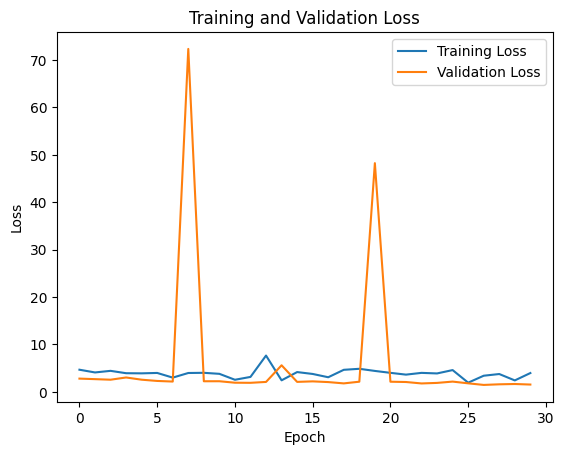

In [ ]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

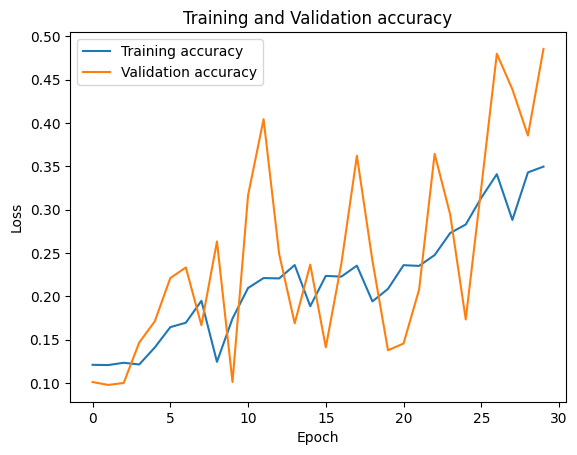

In [ ]:
# Plot training and validation loss
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

29/29 [==============================] - 1s 17ms/step
Test Accuracy: 0.4856


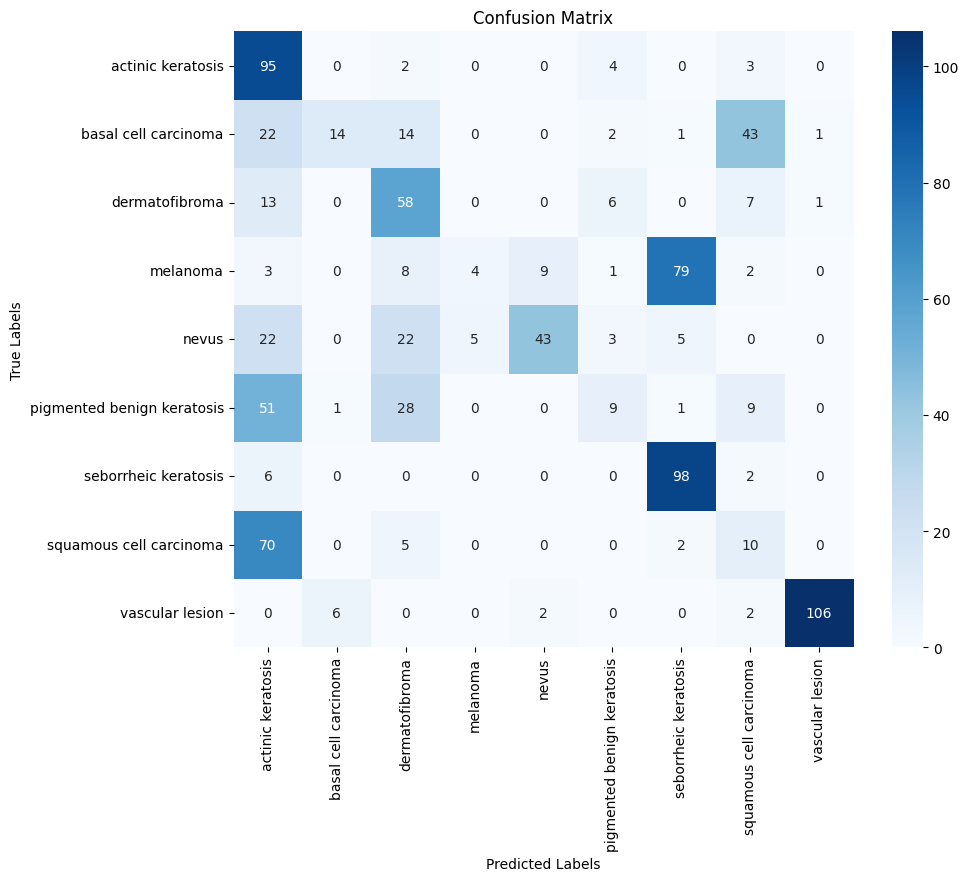

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis     0.3369    0.9135    0.4922       104
      basal cell carcinoma     0.6667    0.1443    0.2373        97
            dermatofibroma     0.4234    0.6824    0.5225        85
                  melanoma     0.4444    0.0377    0.0696       106
                     nevus     0.7963    0.4300    0.5584       100
pigmented benign keratosis     0.3600    0.0909    0.1452        99
      seborrheic keratosis     0.5269    0.9245    0.6712       106
   squamous cell carcinoma     0.1282    0.1149    0.1212        87
           vascular lesion     0.9815    0.9138    0.9464       116

                  accuracy                         0.4856       900
                 macro avg     0.5182    0.4725    0.4182       900
              weighted avg     0.5321    0.4856    0.4308       900



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and predicted classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test

# Calculate test accuracy
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_, digits=4))


In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1
from tensorflow.keras.optimizers import RMSprop
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

num_classes = len(np.unique(labels))

model = models.Sequential()

vgg19_model = VGG19(input_shape=(100, 100, 3), include_top=False, weights='imagenet', pooling='max')

model.add(vgg19_model)

model.add(Dense(128, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(64, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(32, kernel_regularizer=l1(0.0001), activation='relu'))
model.add(BatchNormalization(renorm=True))
model.add(Dropout(0.3))

model.add(Dense(units=num_classes, activation='softmax'))

early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

custom_optimizer = RMSprop(learning_rate=0.0001)
model.compile(optimizer=custom_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))


Epoch 1/30
225/225 [==============================] - 21s 68ms/step - loss: 5.0264 - accuracy: 0.1135 - val_loss: 3.6271 - val_accuracy: 0.1433
Epoch 2/30
225/225 [==============================] - 15s 65ms/step - loss: 4.1212 - accuracy: 0.1169 - val_loss: 2.8239 - val_accuracy: 0.1678
Epoch 3/30
225/225 [==============================] - 15s 65ms/step - loss: 4.6170 - accuracy: 0.1268 - val_loss: 2.7494 - val_accuracy: 0.1833
Epoch 4/30
225/225 [==============================] - 15s 66ms/step - loss: 4.0896 - accuracy: 0.1272 - val_loss: 2.4279 - val_accuracy: 0.1156
Epoch 5/30
225/225 [==============================] - 15s 65ms/step - loss: 3.1391 - accuracy: 0.1576 - val_loss: 2.1767 - val_accuracy: 0.2500
Epoch 6/30
225/225 [==============================] - 15s 66ms/step - loss: 3.4399 - accuracy: 0.1881 - val_loss: 2.2716 - val_accuracy: 0.2867
Epoch 7/30
225/225 [==============================] - 15s 65ms/step - loss: 3.6773 - accuracy: 0.1729 - val_loss: 2.2576 - val_accuracy:

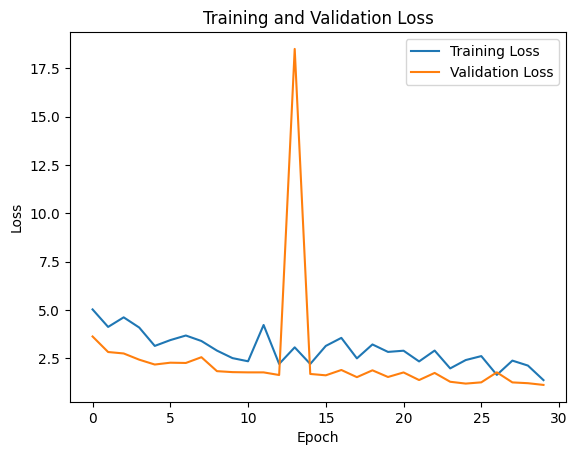

In [ ]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

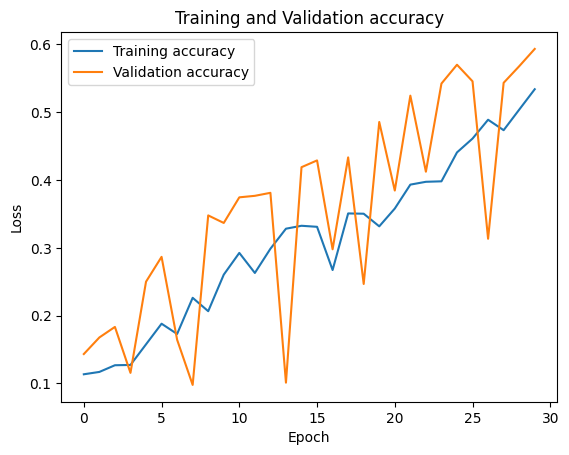

In [ ]:
# Plot training and validation loss
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

29/29 [==============================] - 1s 20ms/step
Test Accuracy: 0.5967


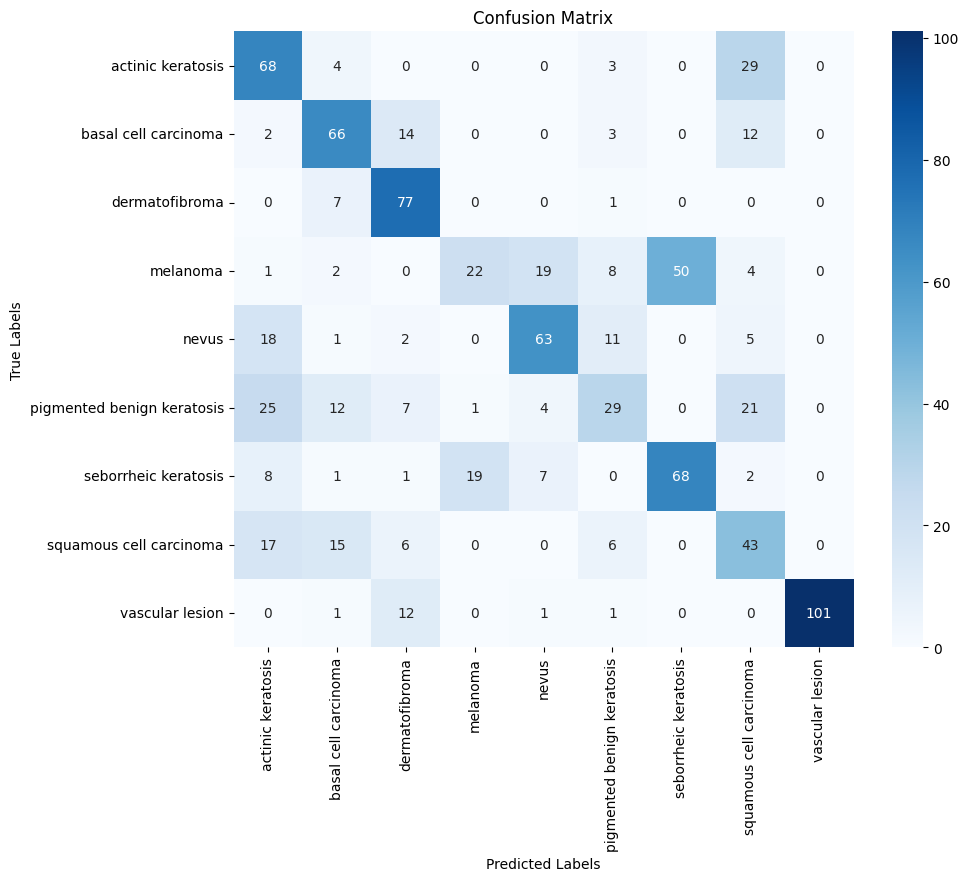

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis     0.4892    0.6538    0.5597       104
      basal cell carcinoma     0.6055    0.6804    0.6408        97
            dermatofibroma     0.6471    0.9059    0.7549        85
                  melanoma     0.5238    0.2075    0.2973       106
                     nevus     0.6702    0.6300    0.6495       100
pigmented benign keratosis     0.4677    0.2929    0.3602        99
      seborrheic keratosis     0.5763    0.6415    0.6071       106
   squamous cell carcinoma     0.3707    0.4943    0.4236        87
           vascular lesion     1.0000    0.8707    0.9309       116

                  accuracy                         0.5967       900
                 macro avg     0.5945    0.5975    0.5804       900
              weighted avg     0.6031    0.5967    0.5843       900



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and predicted classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test

# Calculate test accuracy
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_, digits=4))
